In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# todo: add best of five simulation

In [2]:
def result_cleaning(results: pd.DataFrame) -> pd.DataFrame:
    """
    Due to missing permutations some results need to be manually fixed.
    Rank x should not have a higher worst rank than rank x-1
    """
    results_cleaned = results.copy().reset_index()
    to_loop = results_cleaned.current_ranking.tolist()
    for idx in to_loop[1:]:
        a = results_cleaned.worst_ranking[idx-1]
        b = results_cleaned.worst_ranking[idx-2]
        if b > a:
            results_cleaned.loc[idx-1,'worst_ranking'] = b
    return results_cleaned

In [3]:
# Globals
NUM_PARTICIPANTS = 128
NUM_SIMULATIONS = int(5e6)

In [4]:
# Point distribution
points_per_position = [1000,700,600,500,400,300,200,100,
                       96,92,88,84,80,76,72,68,
                       64,64,60,60,56,56,52,52,
                       48,48,44,44,40,40,36,36,
                       32,32,30,30,28,28,26,26,
                       24,24,22,22,20,20,18,18,
                       16,16,14,14,12,12,10,10,
                       8,8,6,6,4,4,2,2]
points_per_position = points_per_position + (NUM_PARTICIPANTS-64)*[0]

In [5]:
# Actual ranking
df = pd.read_csv('resultsaftergreece.csv')
df.columns = ['rank', 'ewc', 'enc', 'country', 'name', 'china', 'france',
       'usa', 'brazil', 'greece', '? #6', '? #7', '? #8', '? #9',
       '? #10', 'total_points']
df = df[['name','total_points']]
df = df.set_index('name')

# Synthetic players
names = [f'synthetic_player_{x+1}' for x in range(NUM_PARTICIPANTS-len(df))]
df_synth = pd.DataFrame(names,len(names)*[0]).reset_index()
df_synth.columns = ['total_points','name']
df_synth = df_synth.set_index('name')

# Merging
df = pd.concat([df,df_synth])
df['ranking'] = df.reset_index().index+1

In [6]:
# Monte-Carlo-Simulation
np.random.seed(10000) #Why 10k? That is the amount of money Granady lost at Red Bull Faster
randmat = np.random.randint(1,100,size=(NUM_PARTICIPANTS,NUM_SIMULATIONS),dtype=np.uint8)
idx = np.argsort(randmat,axis=0)
arr = np.array(points_per_position)
matrix = arr[idx]

simulation = pd.DataFrame(np.argsort(np.argsort(-(df.total_points.to_numpy().reshape(-1,1)+matrix),axis=0),axis=0)+1)

simulation = pd.concat([simulation.min(axis=1),simulation.max(axis=1)],axis=1)
simulation.index = df.index
simulation['old_ranking'] = df.ranking
simulation.columns = ['best_ranking','worst_ranking','current_ranking']
simulation = simulation.sort_values(by='current_ranking')

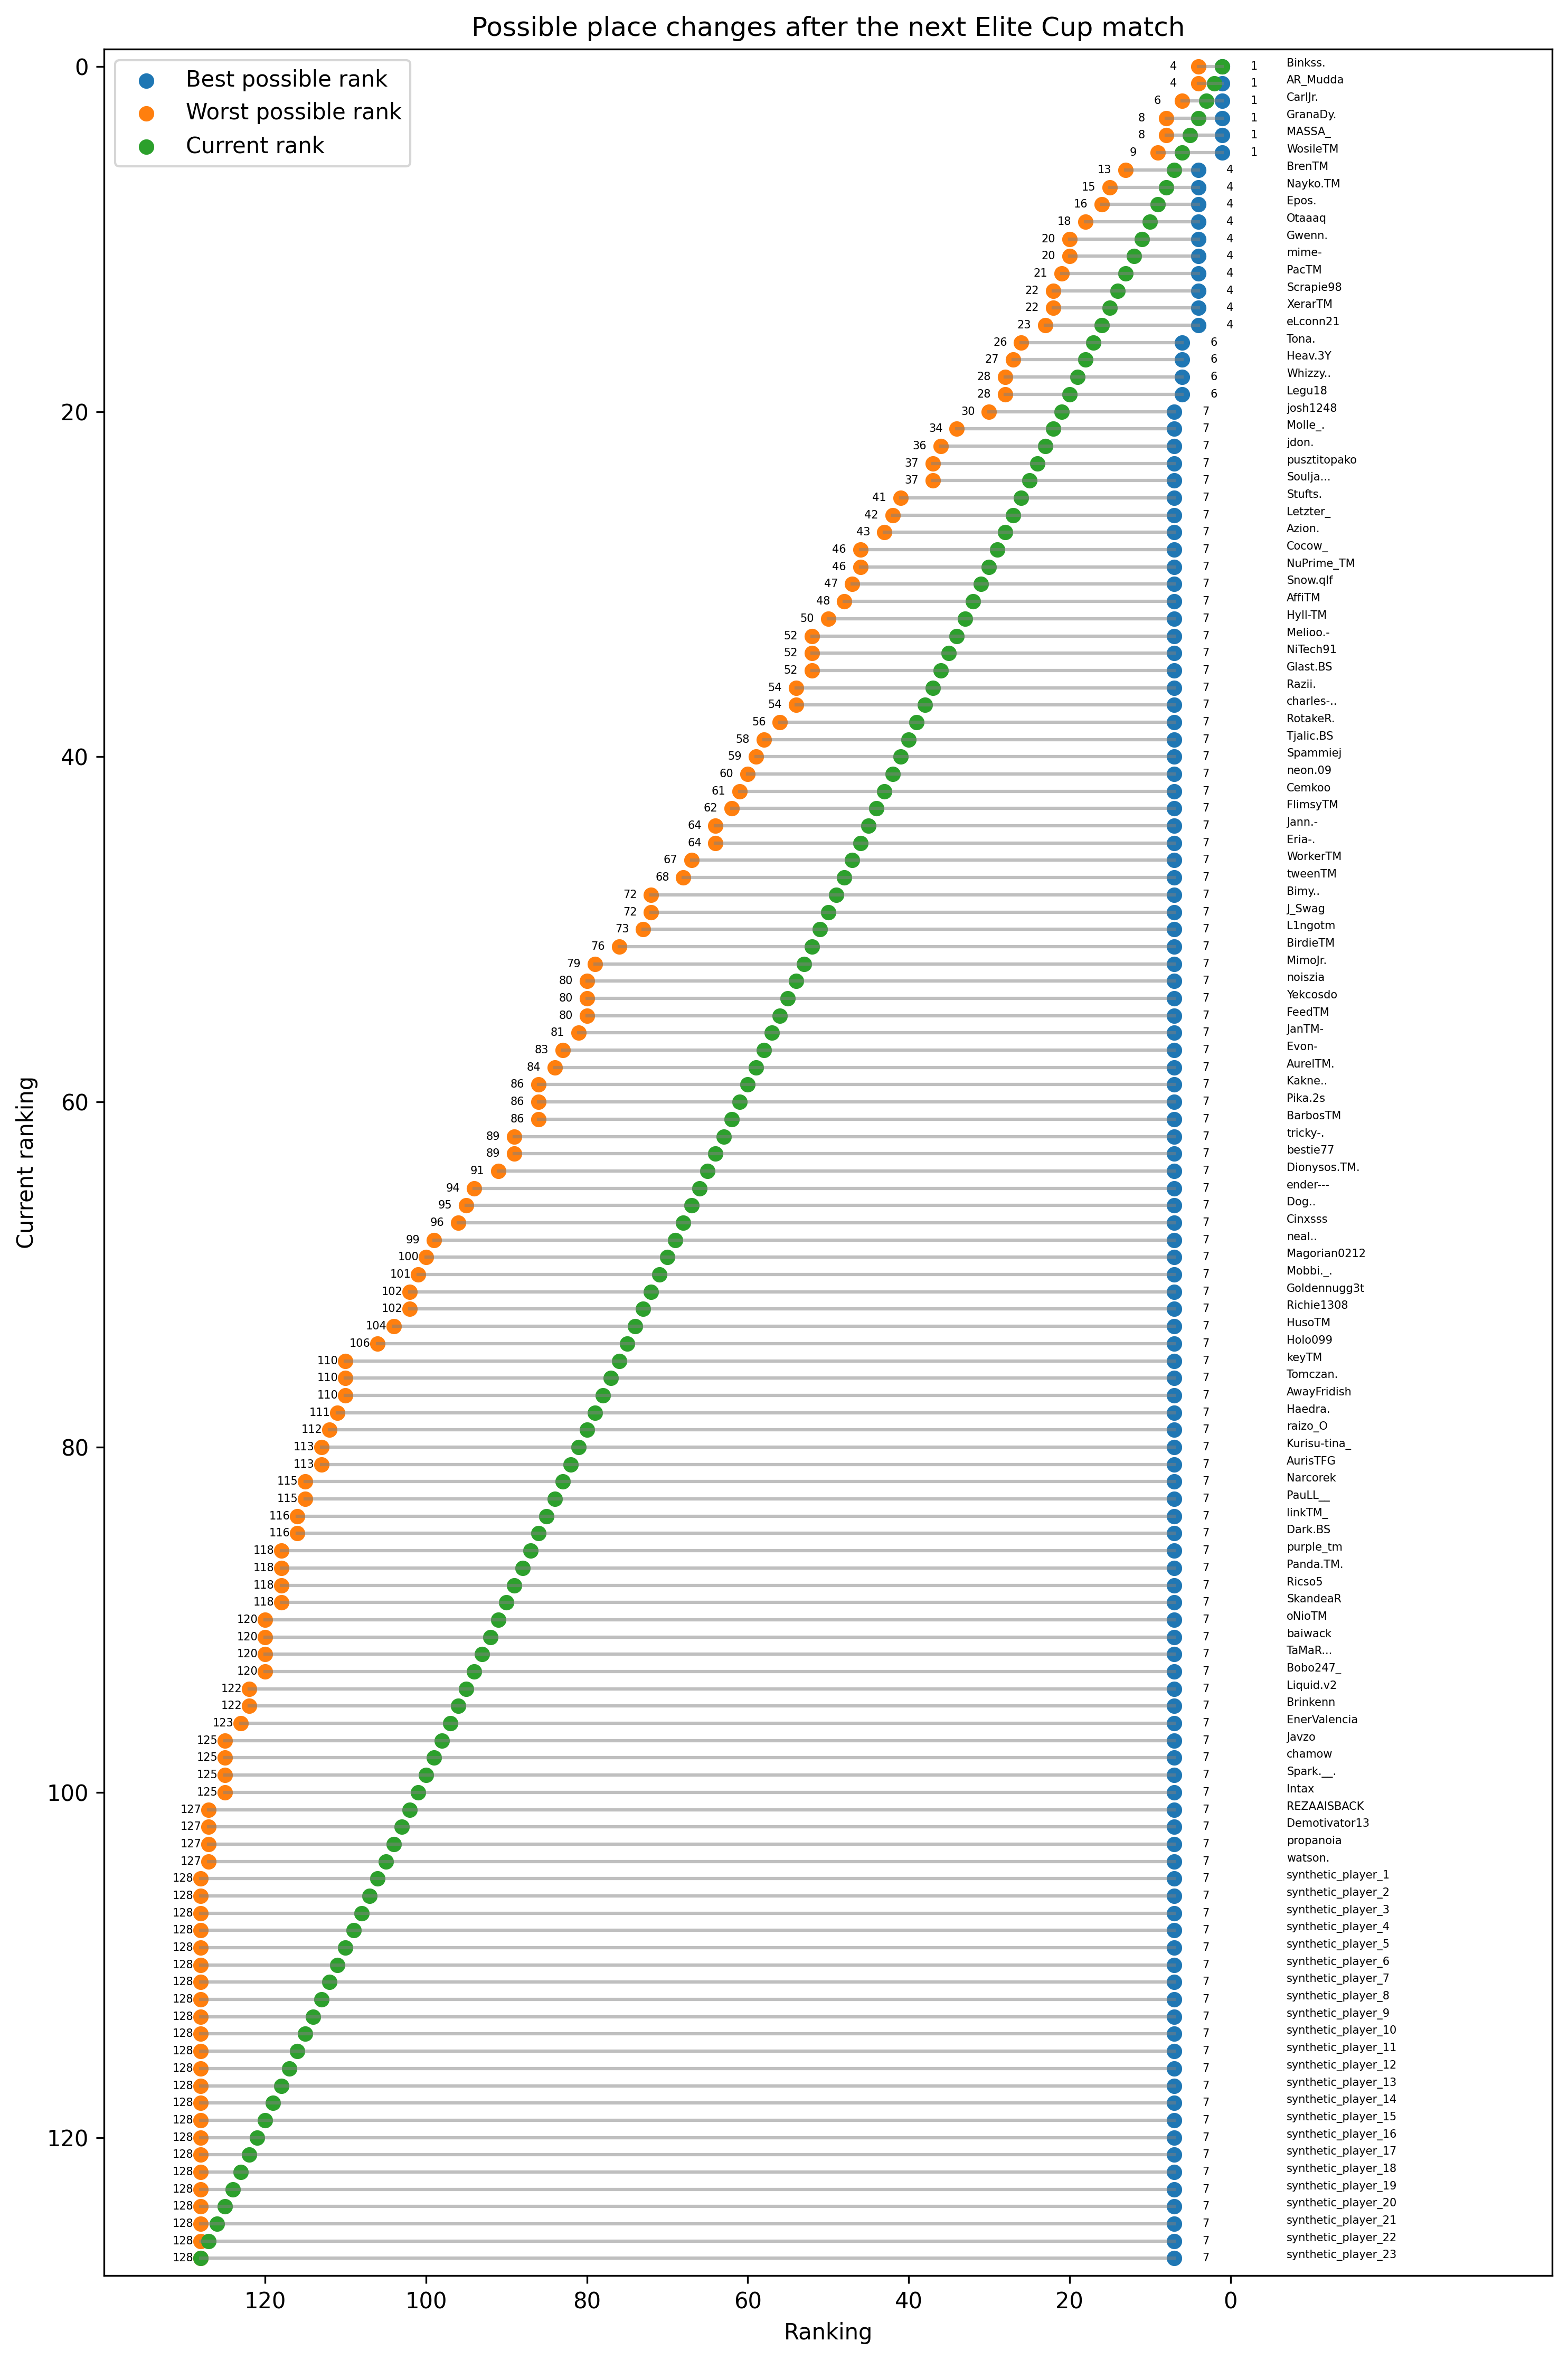

In [7]:
# Visualization
fig, ax = plt.subplots(1,1,figsize=(10,15),dpi=300)
to_plot = result_cleaning(simulation).copy()

ax.scatter(to_plot.best_ranking,to_plot.index)
ax.scatter(to_plot.worst_ranking,to_plot.index)
ax.scatter(to_plot.current_ranking,to_plot.index)

for idx in to_plot.index:
    ax.plot([to_plot.worst_ranking[idx],to_plot.best_ranking[idx]],[idx,idx],color='gray',alpha=0.5)
    try:
        ax.text(-7,idx,to_plot.name[idx],size=5)
    except AttributeError:
        ax.text(-7,idx,to_plot['index'][idx],size=5)
    ax.text(to_plot.worst_ranking[idx]+3.5,idx,to_plot.worst_ranking[idx],va='center',size=5)
    ax.text(to_plot.best_ranking[idx]-3.5,idx,to_plot.best_ranking[idx],va='center',size=5)

ax.set_xlim(-40,140)
ax.set_ylim(-1,128)
ax.set_xticks([0,20,40,60,80,100,120])

ax.invert_xaxis()
ax.invert_yaxis()

ax.set_xlabel('Ranking')
ax.set_ylabel('Current ranking')
ax.set_title('Possible place changes after the next Elite Cup match')
ax.legend(['Best possible rank','Worst possible rank','Current rank'],loc='upper left')
fig.tight_layout()
# fig.savefig('20260307_elitecupchangesaftermap6.png', format='png', pad_inches=0, dpi=300)